In [15]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime.fake_provider import FakeMumbaiV2
from qiskit.converters import circuit_to_dag, dag_to_circuit

import sys
sys.path.append("../../")
from clapton.clapton import claptonize
from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, transform_qiskit_to_stim,generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,compute_optimal_max_cut,build_max_cut_paulis
from testing_scripts.qaoa_utils import QAOASolver, evaluate_energy

import numpy as np
import qubovert

import pcbo_utils
from qiskit.quantum_info import SparsePauliOp

In [ ]:
n_qubits = 8 
feature_set, feature_to_idx, first_corr_arr, second_corr_arr, third_corr_arr = pcbo_utils.load_features_and_corr_files(f'sampled_{n_qubits}_features_subproblem_1')

pcbo_obj = pcbo_utils.create_three_body_cubo(
    feature_set,
    first_corr_arr,
    second_corr_arr,
    third_corr_arr,
    feature_to_idx,
    select_n_features=4,
)

pubo = {key: float(value) for key, value in pcbo_obj.to_pubo().items()}

{(0,): -7000.3674775052195,
 (1,): -7000.267076428868,
 (2,): -7000.307541747743,
 (3,): -7000.25933123445,
 (4,): -7000.135348848076,
 (5,): -7000.279097862935,
 (6,): -7000.228416693991,
 (7,): -7000.336547331394,
 (0, 1): 1999.2186279296875,
 (0, 2): 1999.2137451171875,
 (0, 3): 1999.3369140625,
 (0, 4): 1999.442138671875,
 (0, 5): 1999.3472900390625,
 (0, 6): 1999.3045654296875,
 (0, 7): 1999.1253662109375,
 (1, 2): 1999.203369140625,
 (1, 3): 1999.343505859375,
 (1, 4): 1999.5179443359375,
 (1, 5): 1999.32666015625,
 (1, 6): 1999.4111328125,
 (1, 7): 1999.2515869140625,
 (2, 3): 1999.307373046875,
 (2, 4): 1999.5096435546875,
 (2, 5): 1999.3206787109375,
 (2, 6): 1999.3834228515625,
 (2, 7): 1999.3365478515625,
 (3, 4): 1999.5550537109375,
 (3, 5): 1999.300537109375,
 (3, 6): 1999.3958740234375,
 (3, 7): 1999.2366943359375,
 (4, 5): 1999.572998046875,
 (4, 6): 1999.6087646484375,
 (4, 7): 1999.4693603515625,
 (5, 6): 1999.3980712890625,
 (5, 7): 1999.3531494140625,
 (6, 7): 1999.3

In [ ]:
def convert_pubo_to_ising(hypergraph: dict) -> list[tuple[str, float]]:
    """Convert a hypergraph dictionary to a list of Pauli strings with weights."""
    n = n_qubits # Number of qubits
    pauli_list = []

    for edge, weight in hypergraph.items():
        if edge:  # Ensure the edge is not empty
            # Create a Pauli string with "I" for all qubits
            paulis = ["I"] * n
            # Replace "I" with "Z" for qubits in the edge
            for node in edge:
                paulis[node] = "Z"
            # Append the reversed Pauli string and weight to the list
            pauli_list.append(("".join(paulis[::-1]), weight))

    return pauli_list

max_cut_paulis = convert_pubo_to_ising(pubo)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
cost_hamiltonian

UnboundLocalError: local variable 'paulis' referenced before assignment

In [10]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
circuit

In [11]:
teague_qaoa = QAOASolver(cost_hamiltonian,circuit)
teague_qaoa.prepare_circuit()

dict_items([((0,), np.float64(-7000.3674775052195)), ((1,), np.float64(-7000.267076428868)), ((2,), np.float64(-7000.307541747743)), ((3,), np.float64(-7000.25933123445)), ((4,), np.float64(-7000.135348848076)), ((5,), np.float64(-7000.279097862935)), ((6,), np.float64(-7000.228416693991)), ((7,), np.float64(-7000.336547331394)), ((0, 1), np.float32(1999.2186)), ((0, 2), np.float32(1999.2137)), ((0, 3), np.float32(1999.3369)), ((0, 4), np.float32(1999.4421)), ((0, 5), np.float32(1999.3473)), ((0, 6), np.float32(1999.3046)), ((0, 7), np.float32(1999.1254)), ((1, 2), np.float32(1999.2034)), ((1, 3), np.float32(1999.3435)), ((1, 4), np.float32(1999.518)), ((1, 5), np.float32(1999.3267)), ((1, 6), np.float32(1999.4111)), ((1, 7), np.float32(1999.2516)), ((2, 3), np.float32(1999.3074)), ((2, 4), np.float32(1999.5096)), ((2, 5), np.float32(1999.3207)), ((2, 6), np.float32(1999.3834)), ((2, 7), np.float32(1999.3365)), ((3, 4), np.float32(1999.555)), ((3, 5), np.float32(1999.3005)), ((3, 6), n

In [6]:
# we can perform CAFQA by using the main optimization function "claptonize"
teague_qaoa.run_CAFQA(n_gens=10)

STARTING ROUND 0


started GA at id 1 with 1 procs

started GA at id 2 with 1 procs


started GA at id 3 with 1 procs
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
started GA at id None with 1 procs

GA parameters used for this experiment:
  num_generations=5
  num_parents_mating=20
  population_size=100
  num_genes=200
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=ada

Caught signal 2. Killed all subprocesses. Terminated.
Traceback (most recent call last):
  File "/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py", line 1967, in run
    self.run_mutation()
  File "/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/pygad.py", line 2276, in run_mutation
    self.last_generation_offspring_mutation = self.mutation(self.last_generation_offspring_crossover)
  File "/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/utils/mutation.py", line 651, in adaptive_mutation
    offspring = self.adaptive_mutation_probs_by_space(offspring)
  File "/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/pygad/utils/mutation.py", line 906, in adaptive_mutation_probs_by_space
    average_fitness, offspring_fitness = self.adaptive_mutation_population_fitness(offspring)
  File "/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-pa

killed child psutil.Process(pid=1653225, name='python', status='sleeping', started='14:37:57')
killed child psutil.Process(pid=1653230, name='python', status='running', started='14:37:57')
killed child psutil.Process(pid=1653234, name='python', status='sleeping', started='14:37:57')
killed child psutil.Process(pid=1653240, name='python', status='running', started='14:37:57')
killed child psutil.Process(pid=1653947, name='python', status='sleeping', started='14:38:06')
killed child psutil.Process(pid=1653966, name='python', status='sleeping', started='14:38:06')
killed child psutil.Process(pid=1653967, name='python', status='running', started='14:38:06')
killed child psutil.Process(pid=1653933, name='python', status='sleeping', started='14:38:06')


Exception: Caught signal 2. Killed all subprocesses. Terminated.

In [ ]:
teague_qaoa.energy_best

np.float64(-9000.462603108466)

In [ ]:
# Solve with classical Eigensolver for comparison
exact_solution = teague_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -20006.446190868308


In [25]:
cafqa_angles = [param * np.pi/2 for param in teague_qaoa.ks_best]

In [26]:
energies = [evaluate_energy(teague_qaoa.pcirc,cost_hamiltonian, cafqa_angles) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -8905.300769988828


In [28]:
# Random Initalization
random_angles = np.random.random(len(teague_qaoa.ks_best))
random_energies = [evaluate_energy(teague_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 5066.243655581308


In [29]:
cafqa_result,cafqa_iteration_vals = teague_qaoa.run_qaoa(cafqa_angles,max_iters=10)
random_result,random_iteration_vals = teague_qaoa.run_qaoa(random_angles,max_iters=10)

In [30]:
cafqa_result

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -9365.990448701199
       x: [ 5.712e+00  5.712e+00 ...  1.571e+00  1.571e+00]
    nfev: 10
   maxcv: 0.0

In [21]:
# Solve with classical Eigensolver for comparison
eigensolver = NumPyMinimumEigensolver()
exact_solution = eigensolver.compute_minimum_eigenvalue(cost_hamiltonian).eigenvalue.real
print("Exact Energy from Eigensolver:", exact_solution)

Exact Energy from Eigensolver: -20006.446190868308


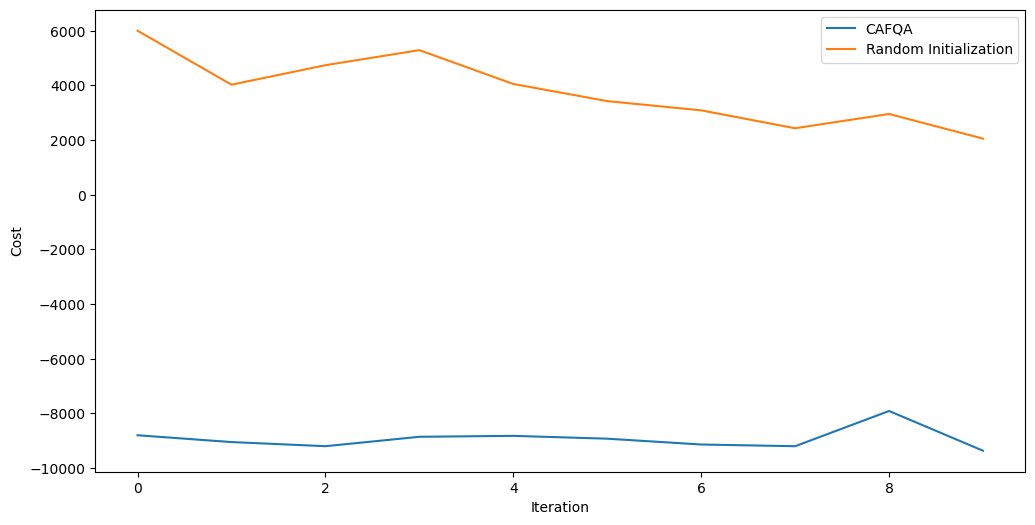

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()